# Predicción de satisfacción de clientes en vuelos
## Modelo Fase 2 - Post-vuelo

Este modelo tiene como objetivo predecir la satisfacción utilizando todas las variables históricas del vuelo (demografía, detalles del viaje, retrasos y calificaciones del servicio a bordo) recolectadas post-vuelo.

---
## Importación de librerías

In [ ]:
from pathlib import Path
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
from sklearn.metrics import log_loss, roc_auc_score
import warnings

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
warnings.filterwarnings('ignore')

---
## Carga de datos

In [3]:
def load_airline_data():
    csv_path = Path.home() / "Downloads" / "Invistico_Airline.csv"
    
    if not csv_path.is_file():
        csv_path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://github.com/AgustinaHourcade/airline-passenger-satisfaction/blob/main/Invistico_Airline.csv"
        urllib.request.urlretrieve(url, csv_path)
        
    return pd.read_csv(csv_path)

df = load_airline_data()
print(f"Forma del dataset: {df.shape}")

Forma del dataset: (129880, 23)


---
## División Train / Test (Hold-Out)
**80 % entrenamiento — 20 % prueba**, con estratificación para preservar la proporción original de clases (≈54.7 % satisfechos / 45.3 % insatisfechos) en ambos conjuntos.

**Prevención de Fugas (Data Leakage)**: Es crucial destacar que esta división se realiza **antes** de cualquier preprocesamiento. Al asegurar que no haya fuga de información del conjunto de test hacia el de entrenamiento, garantizamos que las métricas de evaluación reflejarán el verdadero rendimiento del modelo ante datos no vistos.

In [4]:
df['Satisfaction_bin'] = (df['satisfaction'] == 'satisfied').astype(int)

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['Satisfaction_bin']
)

print(f"Tamaño Train: {df_train.shape[0]:,} registros")
print(f"Tamaño Test: {df_test.shape[0]:,} registros")

Tamaño Train: 103,904 registros
Tamaño Test: 25,976 registros


La división elegida hold-out 80/20 deja un conjunto de entrenamiento de 103,904 instancias y uno de prueba de 25,976. Con esos volúmenes, se puede hipotetizar que ambos subconjuntos son estadísticamente representativos de la distribución original.

El punto más importante del diseño es la estratificación. Al forzar que ambas particiones mantengan la misma proporción de clases (≈54.7 % / 45.3 %), se evita que un split aleatorio desfavorable termine concentrando la clase minoritaria en el set de entrenamiento o en el de prueba. Esto es especialmente relevante para el Modelo Pre-vuelo: dado que sus features tienen menor poder discriminativo que las puntuaciones de servicio, se postula que ese modelo es más sensible a cualquier desbalance espurio en la proporción de clases que llegue al entrenamiento.

Una proporción 54/46 es moderada, lejos del umbral donde técnicas como SMOTE o submuestreo se vuelven necesarias. Sin embargo, se hipotetiza que incluso este desbalance leve puede inclinar al clasificador a favorecer la clase mayoritaria en escenarios donde la señal predictiva es débil, algo que habría que monitorear en el recall de la clase "insatisfecho" del Modelo Pre-vuelo.

In [5]:
# Imputación de nulos
median_arrival = df_train['Arrival Delay in Minutes'].median()
print(f"Mediana de Arrival Delay calculada en Train: {median_arrival}")

df_train = df_train.copy()
df_test = df_test.copy()

df_train['Arrival Delay in Minutes'] = df_train['Arrival Delay in Minutes'].fillna(median_arrival)
df_test['Arrival Delay in Minutes'] = df_test['Arrival Delay in Minutes'].fillna(median_arrival)

df_train['Total Delay'] = df_train['Departure Delay in Minutes'] + df_train['Arrival Delay in Minutes']
df_test['Total Delay'] = df_test['Departure Delay in Minutes'] + df_test['Arrival Delay in Minutes']

print("Valores nulos en Train:", df_train['Arrival Delay in Minutes'].isnull().sum())
print("Valores nulos en Test:", df_test['Arrival Delay in Minutes'].isnull().sum())

Mediana de Arrival Delay calculada en Train: 0.0
Valores nulos en Train: 0
Valores nulos en Test: 0


### Análisis de Departure Delay in Minutes
En este apartado se analizará qué decisión tomar respecto a las variables Departure Delay in Minutes y Arrival Delay in Minutes, dado que el Análisis Exploratorio de Datos (EDA) reveló una colinealidad crítica de 0.96 entre ambas. Para evitar la redundancia de información sin perder poder predictivo, evaluaremos el rendimiento de tres alternativas: conservar únicamente el retraso de llegada, conservar únicamente el de salida, o crear una nueva variable que combine ambas (su suma). Se compararán estas tres configuraciones de features utilizando validación cruzada (cross-validation) sobre el conjunto de entrenamiento mediante un modelo de Regresión Logística, empleado aquí como un proxy rápido y sin ajuste de hiperparámetros. Aquella configuración que logre el mayor F1-score promedio será la elegida para integrarse en los pipelines finales.

Hipótesis de negocio: Se hipotetiza que el retraso de llegada es el factor más directamente percibido por el pasajero y, por tanto, podría estar más asociado a la insatisfacción que el retraso de salida.


In [6]:
df_eval = df_train.copy()
df_eval['Gender'] = (df_eval['Gender'] == 'Female').astype(int)
df_eval['Customer Type'] = (df_eval['Customer Type'] == 'Loyal Customer').astype(int)
df_eval['Type of Travel'] = (df_eval['Type of Travel'] == 'Business travel').astype(int)
df_eval = pd.get_dummies(df_eval, columns=['Class'], drop_first=False)

class_dummies = [c for c in df_eval.columns if c.startswith('Class_')]
non_delay_features = [
    'Age', 'Flight Distance',
    'Seat comfort', 'Departure/Arrival time convenient',
    'Food and drink', 'Gate location', 'Inflight wifi service',
    'Inflight entertainment', 'Online support', 'Ease of Online booking',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness', 'Online boarding',
    'Gender', 'Customer Type', 'Type of Travel',
] + class_dummies

DELAY_CONFIGS = {
    'A — Solo Arrival Delay': ['Arrival Delay in Minutes'],
    'B — Solo Departure Delay': ['Departure Delay in Minutes'],
    'C — Total Delay': ['Total Delay'],
}

TARGET = 'Satisfaction_bin'
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
delay_results = {}

print("Evaluando configuraciones de delay en conjunto de Train...")
for name, delay_cols in DELAY_CONFIGS.items():
    features = non_delay_features + delay_cols
    X_tmp = df_eval[features]
    y_tmp = df_eval[TARGET]

    pipe_tmp = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    scores = cross_val_score(pipe_tmp, X_tmp, y_tmp, cv=cv_strat, scoring='f1', n_jobs=-1)
    delay_results[name] = scores
    print(f"{name:30s}  F1 medio = {scores.mean():.4f}  (±{scores.std():.4f})")

best_delay_name = max(delay_results, key=lambda k: delay_results[k].mean())
best_delay_col  = DELAY_CONFIGS[best_delay_name]
print(f"\nConfiguración seleccionada: {best_delay_name}")

Evaluando configuraciones de delay en conjunto de Train...
A — Solo Arrival Delay          F1 medio = 0.8499  (±0.0023)
B — Solo Departure Delay        F1 medio = 0.8499  (±0.0020)
C — Total Delay                 F1 medio = 0.8500  (±0.0020)

Configuración seleccionada: C — Total Delay


---
## Pipelines con ColumnTransformer

In [7]:
NUMERIC_FEATURES = ['Age', 'Flight Distance'] + best_delay_col
ORDINAL_FEATURES = [
    'Seat comfort', 'Departure/Arrival time convenient',
    'Food and drink', 'Gate location', 'Inflight wifi service',
    'Inflight entertainment', 'Online support', 'Ease of Online booking',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness', 'Online boarding',
]
BINARY_MAP = {
    'Gender': {'Female': 1, 'Male': 0},
    'Customer Type': {'Loyal Customer': 1, 'disloyal Customer': 0},
    'Type of Travel': {'Business travel': 1, 'Personal Travel': 0},
}
ONEHOT_FEATURES = ['Class']

X_train = df_train[NUMERIC_FEATURES + ORDINAL_FEATURES + list(BINARY_MAP.keys()) + ONEHOT_FEATURES].copy()
y_train = df_train['Satisfaction_bin']

X_test = df_test[NUMERIC_FEATURES + ORDINAL_FEATURES + list(BINARY_MAP.keys()) + ONEHOT_FEATURES].copy()
y_test = df_test['Satisfaction_bin']

for col, mapping in BINARY_MAP.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), NUMERIC_FEATURES + ORDINAL_FEATURES),
        ('ohe_class', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ONEHOT_FEATURES),
    ],
    remainder='passthrough'
)

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, solver='lbfgs'))
])

pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

---
## Selección de Modelos y Búsqueda de Hiperparámetros

In [9]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
}

param_grid_dt = {
    'clf__max_depth': [10, 15, 20, 25],
    'clf__min_samples_split': [50, 100, 300],
    'clf__min_samples_leaf': [20, 50, 100],
    'clf__criterion': ['gini', 'entropy'],
}

param_grid_rf = {
    'clf__n_estimators':[100, 200],
    'clf__max_depth': [10, 15, 20],
    'clf__min_samples_split': [50, 100, 200],
    'clf__max_features':['sqrt'],
}

search_configs = [
    ('Logistic Regression', pipe_lr, param_grid_lr),
    ('Decision Tree', pipe_dt, param_grid_dt),
    ('Random Forest', pipe_rf, param_grid_rf),
]

best_models  = {}
grid_results = {}

for model_name, pipeline, param_grid in search_configs:
    print(f"\n{model_name}")
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv_strat,
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(X_train, y_train)
    best_models[model_name]  = gs.best_estimator_
    grid_results[model_name] = gs
    print(f"Mejores parámetros: {gs.best_params_}")
    print(f"Mejor F1 (CV Train): {gs.best_score_:.4f}")

print("\nGridSearchCV finalizado")


Logistic Regression
Mejores parámetros: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Mejor F1 (CV Train): 0.8358

Decision Tree
Mejores parámetros: {'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__min_samples_leaf': 20, 'clf__min_samples_split': 50}
Mejor F1 (CV Train): 0.9396

Random Forest
Mejores parámetros: {'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 50, 'clf__n_estimators': 200}
Mejor F1 (CV Train): 0.9492

GridSearchCV finalizado


Random Forest alcanzó el mejor F1 de CV con n_estimators=200, max_depth=20 y min_samples_split=50. Es el valor más alto del grid en número de árboles, lo que indica que agregar más estimadores seguía aportando mejoras dentro del rango explorado, a diferencia del Modelo Pre-vuelo, donde el ensamble no superaba al árbol individual. Esto tiene sentido: con más features informativas y relaciones más complejas entre ellas, el mecanismo de bagging tiene más varianza que reducir y el promedio de múltiples árboles empieza a marcar diferencia real.

La brecha de 0.0096 sobre el Decision Tree (0.9492 vs. 0.9396) y el hecho de que ambos compartan max_depth=20 y min_samples_split=50 sugiere que la ganancia del Random Forest viene principalmente de la decorrelación entre árboles, no de una estructura individual más profunda.

---
## Métricas - Test


Logistic Regression
Accuracy: 0.8363
F1-score: 0.8363
Log Loss: 0.3837
ROC-AUC: 0.9097
              precision    recall  f1-score   support

dissatisfied       0.82      0.82      0.82     11759
   satisfied       0.85      0.85      0.85     14217

    accuracy                           0.84     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.84      0.84      0.84     25976


Decision Tree
Accuracy: 0.9408
F1-score: 0.9408
Log Loss: 0.2277
ROC-AUC: 0.9870
              precision    recall  f1-score   support

dissatisfied       0.93      0.94      0.93     11759
   satisfied       0.95      0.94      0.95     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976


Random Forest
Accuracy: 0.9530
F1-score: 0.9530
Log Loss: 0.1404
ROC-AUC: 0.9916
              precision    recall  f1-score   support

dissatisfied       0.94      0.95      

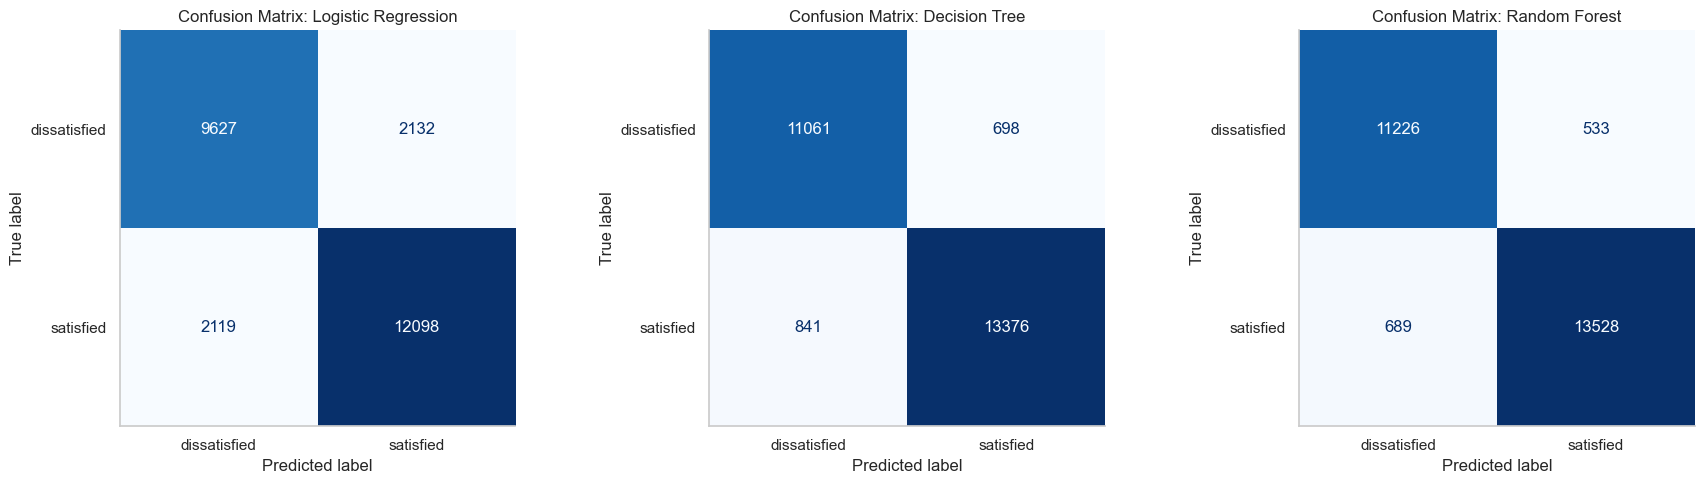

,Accuracy,F1-score,Log Loss,ROC-AUC
Modelo,,,,
Logistic Regression,0.8363,0.8363,0.3837,0.9097
Decision Tree,0.9408,0.9408,0.2277,0.9870
Random Forest,0.9530,0.9530,0.1404,0.9916



Modelo con mayor F1-score: Random Forest  (F1 = 0.9530)


In [10]:
results_summary = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model_name, model) in enumerate(best_models.items()):
    print(f"\n{model_name}")
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
        
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Log Loss: {loss:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['dissatisfied', 'satisfied']))
    
    results_summary.append({
        'Modelo': model_name,
        'Accuracy': acc,
        'F1-score': f1,
        'Log Loss': loss,
        'ROC-AUC': roc_auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['dissatisfied', 'satisfied']
    )
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {model_name}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results_summary).set_index('Modelo')
display(df_results.style.background_gradient(cmap='Blues', axis=0).format('{:.4f}'))

best_model_name = df_results['F1-score'].idxmax()
print(f"\nModelo con mayor F1-score: {best_model_name}  (F1 = {df_results.loc[best_model_name, 'F1-score']:.4f})")

Incorporar las puntuaciones de experiencia a bordo lleva al Random Forest de un F1 de ~0.79 a 0.9530, al Decision Tree de ~0.79 a 0.9408, y a la Regresión Logística de ~0.76 a 0.8363. Los tres modelos mejoran, pero no en la misma proporción — los modelos no lineales se benefician mucho más que el lineal, lo que refuerza la idea de que las relaciones entre las variables de servicio y la satisfacción tienen una estructura compleja que un modelo lineal no captura del todo.

El patrón más relevante al comparar ambas fases es el comportamiento de la clase "dissatisfied". En la Fase 1 era consistentemente la más difícil de predecir — recall de 0.65 en Regresión Logística, 0.71–0.72 en los árboles. En la Fase 2, ese problema desaparece: el Random Forest alcanza un recall de 0.95 para dissatisfied, casi idéntico al de satisfied. Esto sugiere que los pasajeros insatisfechos sí tienen un perfil de experiencia a bordo diferenciado y detectable, simplemente ese perfil no era visible con las variables pre-vuelo.

La mejora masiva confirma la hipótesis central del proyecto: la satisfacción del pasajero no está predeterminada por quién es o cómo viaja, sino por lo que experimenta durante el vuelo.

Evaluando profundidad: 5...
Evaluando profundidad: 7...
Evaluando profundidad: 9...
Evaluando profundidad: 11...
Evaluando profundidad: 13...
Evaluando profundidad: 15...
Evaluando profundidad: 17...
Evaluando profundidad: 19...
Evaluando profundidad: 21...
Evaluando profundidad: 23...
Evaluando profundidad: 25...


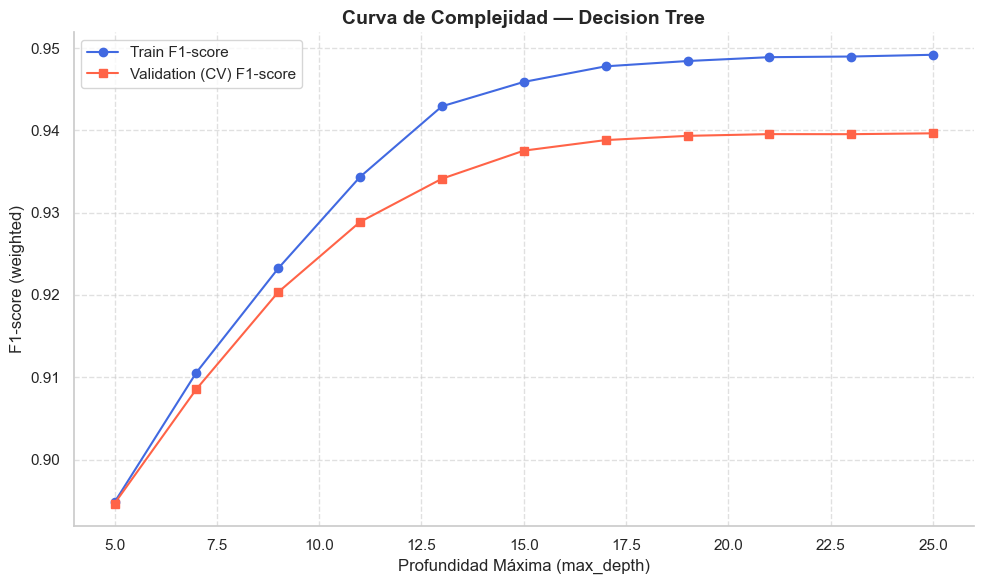

In [11]:
depths = list(range(5, 26, 2))
train_scores_depth = []
val_scores_depth = []

for depth in depths:
    print(f"Evaluando profundidad: {depth}...")
    pipe_tmp = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(max_depth=depth, min_samples_split=50, min_samples_leaf=20, random_state=42))
    ])
    
    pipe_tmp.fit(X_train, y_train)
    train_pred = pipe_tmp.predict(X_train)
    train_scores_depth.append(f1_score(y_train, train_pred, average='weighted'))
    
    scores = cross_val_score(pipe_tmp, X_train, y_train, cv=cv_strat, scoring='f1_weighted', n_jobs=-1)
    val_scores_depth.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores_depth, label='Train F1-score', marker='o', color='royalblue')
plt.plot(depths, val_scores_depth, label='Validation (CV) F1-score', marker='s', color='tomato')
plt.title('Curva de Complejidad — Decision Tree', fontweight='bold', fontsize=14)
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('F1-score (weighted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---
## Importancia de variables - Random Forest

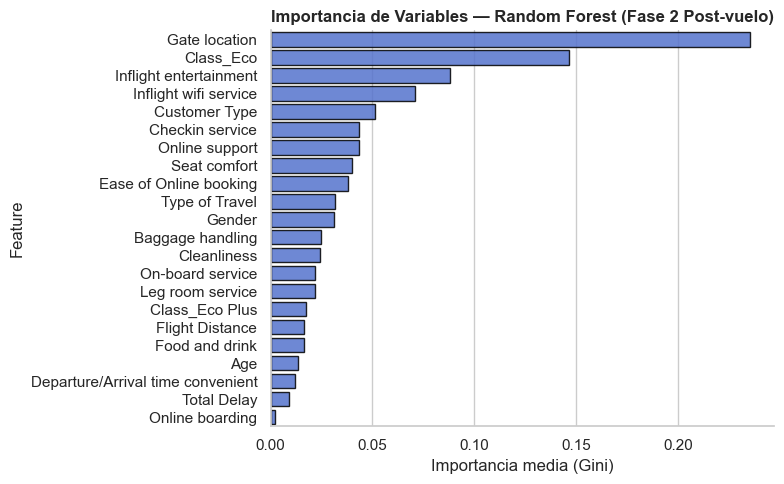

,Feature,Importance
0,Gate location,0.235455
1,Class_Eco,0.146397
2,Inflight entertainment,0.087940
3,Inflight wifi service,0.071024
4,Customer Type,0.051111
5,Checkin service,0.043627
6,Online support,0.043281
7,Seat comfort,0.040093
8,Ease of Online booking,0.038128
9,Type of Travel,0.031650


In [12]:
rf_pipeline = best_models['Random Forest']
rf_clf = rf_pipeline.named_steps['clf']
preprocessor_fit = rf_pipeline.named_steps['preprocessor']

ohe_feature_names = (
    preprocessor_fit
    .named_transformers_['ohe_class']
    .get_feature_names_out(ONEHOT_FEATURES)
    .tolist()
)

passthrough_names = ORDINAL_FEATURES + list(BINARY_MAP.keys())
all_feature_names = NUMERIC_FEATURES + ohe_feature_names + passthrough_names

importances = rf_clf.feature_importances_
feat_imp_df = (pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feat_imp_df, y='Feature', x='Importance', color='royalblue', alpha=0.85, edgecolor='black', ax=ax)
ax.set_title('Importancia de Variables — Random Forest (Fase 2 Post-vuelo)', fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia media (Gini)')
plt.tight_layout()
plt.show()

display(feat_imp_df)

El resultado más llamativo del ranking es que Gate location encabeza con 0.2355, separándose por un margen amplio del segundo lugar (Class_Eco, 0.146). Desde la perspectiva del negocio, la ubicación de la puerta de embarque no es un servicio que la aerolínea pueda controlar completamente, depende en gran parte de la asignación aeroportuaria. Que aparezca como la variable más importante podría estar reflejando una correlación estructural con otros factores: por ejemplo, ciertas puertas podrían estar sistemáticamente asignadas a vuelos de larga distancia o clases business

**Class_Eco** (0.146) en segundo lugar sí tiene una lectura más directa: volar en economy está asociado a una experiencia más acotada en múltiples dimensiones simultáneamente (espacio, servicio, atención), lo que lo convierte en un predictor potente.

Después de los dos primeros, el ranking muestra un grupo de variables de servicio con importancias más distribuidas: Inflight entertainment (0.088), Inflight wifi service (0.071), Checkin service (0.044), Online support (0.043) y Seat comfort (0.040). Estas variables son las que más directamente representan la experiencia percibida durante y alrededor del vuelo, y su agrupación en importancias similares podría indicar que ningún servicio individual domina la satisfacción por sí solo, sino que es la combinación de varios la que define la experiencia final del pasajero.

Que Inflight entertainment e Inflight wifi aparezcan por encima de variables más tangibles como Seat comfort, Leg room service o Food and drink es un resultado interesante: sugeriría que los pasajeros valoran más la conectividad y el entretenimiento que las comodidades físicas tradicionales, al menos en términos de su impacto en la satisfacción reportada.

Las variables que dominaban en la Fase 1 (Gender, Customer Type, Type of Travel) no desaparecen, pero caen al medio y final del ranking (posiciones 10, 4 y 9 respectivamente). Siguen aportando señal, pero quedan opacadas por las variables de experiencia. Esto es consistente con lo que mostraban las métricas: el perfil del pasajero ayuda a segmentar, pero no determina la satisfacción.

Total Delay (0.009) y Online boarding (0.002) terminan al fondo del ranking. El primero podría ser menos influyente de lo esperado porque los retrasos son relativamente infrecuentes o porque los pasajeros los toleran mejor cuando el resto de la experiencia es positiva. 

Si la aerolínea quisiera priorizar inversiones basándose en este modelo, el ranking sugeriría enfocarse primero en la experiencia digital a bordo (entretenimiento y wifi) y en la consistencia del servicio de check-in y soporte, antes que en mejoras de infraestructura física como espacio o comida. 

---
## Análisis de underfitting / overfitting

El contraste con la Fase 1 es notorio. Antes todos los modelos se estabilizaban en torno a 0.79 sin importar cuánta complejidad se agregara, ahora el Random Forest llega a 0.9530 y el Decision Tree a 0.9408. Esto confirma que el problema de la Fase 1 era de información, no de capacidad de modelado: los algoritmos siempre tuvieron la capacidad de aprender fronteras de decisión complejas, pero no tenían los datos para hacerlo. Al incorporar las puntuaciones de servicio, ese techo desaparece.

En esta fase es que ningún modelo sobreajusta, a pesar de que la complejidad del espacio de features aumentó respecto a la Fase 1
* **Random Forest**: Logra un F1 en Train CV de 0.9492 y en Test de 0.9530. Esta consistencia sólida entre entrenamiento y prueba demuestra que los hiperparámetros optimizados mediante GridSearchCV (como limitar la profundidad y exigir un mínimo de muestras por hoja) han prevenido el overfitting con éxito. El modelo generaliza excepcionalmente bien ante datos nuevos.
* **Decision Tree**: Train F1 de 0.9396 vs Test F1 de 0.9408. También se mantiene sumamente estable, sin señales de caída de rendimiento al exponerlo a datos no vistos.
* **Regresión Logística**: Al ser un modelo lineal, estructuralmente no es propenso a sobreajustar en este dataset (Train 0.8358 vs Test 0.8363). Sin embargo, su menor rendimiento comparado con los modelos basados en árboles indica que la relación entre la experiencia a bordo y la satisfacción contiene patrones y combinaciones no lineales.

La Fase 2 resuelve ambos problemas identificados en la Fase 1: el sesgo estructural desaparece al incorporar features informativas, y la varianza permanece controlada gracias a la regularización vía hiperparámetros. 